# **Line Charts**


## Objectives


- Track trends in compensation across age groups and specific age ranges.

- Analyze job satisfaction trends based on experience level.

- Explore and interpret line charts to identify patterns and trends.


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 182.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 148.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]


In [2]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 138.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 137.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 128.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


#### Import necessary libraries and load the dataset


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


#### Load the data


In [2]:
df = pd.read_csv("survey-data.csv")


#### Display the first few rows to understand the structure of the data


In [3]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Trends in Compensation Over Age Groups


##### 1. Line Chart of Median `ConvertedCompYearly` by Age Group


- Track how the median yearly compensation (ConvertedCompYearly) changes across different age groups.

- Use a line chart to visualize these trends.


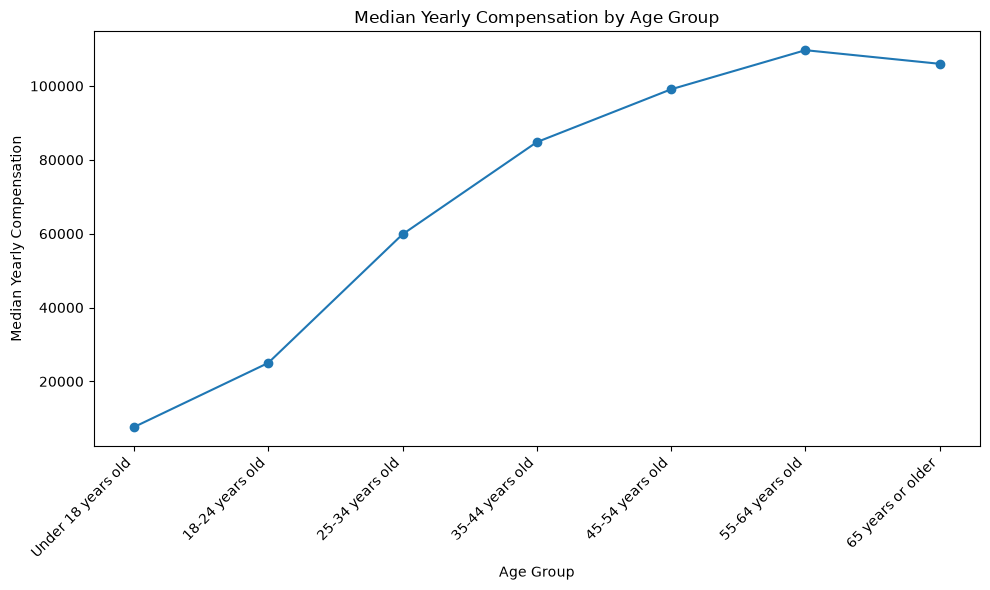

In [7]:
# Median yearly compensation by age group

age_order = [
    "Under 18 years old", "18-24 years old", "25-34 years old",
    "35-44 years old", "45-54 years old", "55-64 years old",
    "65 years or older"
]

plot_df = df[["Age", "ConvertedCompYearly"]].copy()
plot_df["ConvertedCompYearly"] = pd.to_numeric(plot_df["ConvertedCompYearly"], errors="coerce")
plot_df = plot_df.dropna()

table = plot_df.groupby("Age")["ConvertedCompYearly"].median()
table = table.reindex(age_order).dropna()

plt.figure(figsize=(10, 6))
plt.plot(table.index, table.values, marker="o")
plt.title("Median Yearly Compensation by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Median Yearly Compensation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

##### 2. Line Chart of Median `ConvertedCompYearly` for Ages 25 to 45


For a closer look, plot a line chart focusing on the median compensation for respondents between ages 25 and 45.


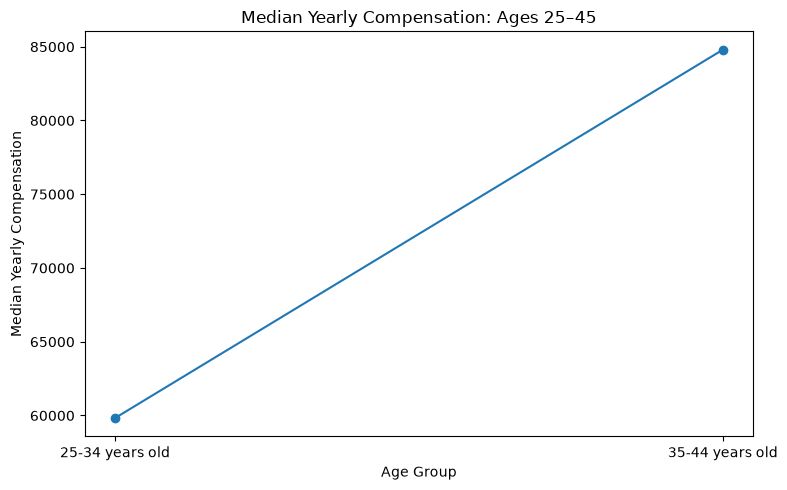

In [19]:
# Median yearly compensation for ages 25 to 45

age_order = ["25-34 years old", "35-44 years old"]

plot_df = df[["Age", "ConvertedCompYearly"]].copy()
plot_df["ConvertedCompYearly"] = pd.to_numeric(plot_df["ConvertedCompYearly"], errors="coerce")
plot_df = plot_df.dropna()
plot_df = plot_df[plot_df["Age"].isin(age_order)]

table = plot_df.groupby("Age")["ConvertedCompYearly"].median().reindex(age_order).dropna()

plt.figure(figsize=(8, 5))
plt.plot(table.index, table.values, marker="o")
plt.title("Median Yearly Compensation: Ages 25–45")
plt.xlabel("Age Group")
plt.ylabel("Median Yearly Compensation")
plt.tight_layout()
plt.show()

### Trends in Job Satisfaction by Experience Level



##### 1. Line Chart of Job Satisfaction (`JobSatPoints_6`) by Experience Level



- Use a column that approximates experience level to analyze how job satisfaction changes with experience.

- If needed, substitute an available experience-related column for `Experience`.


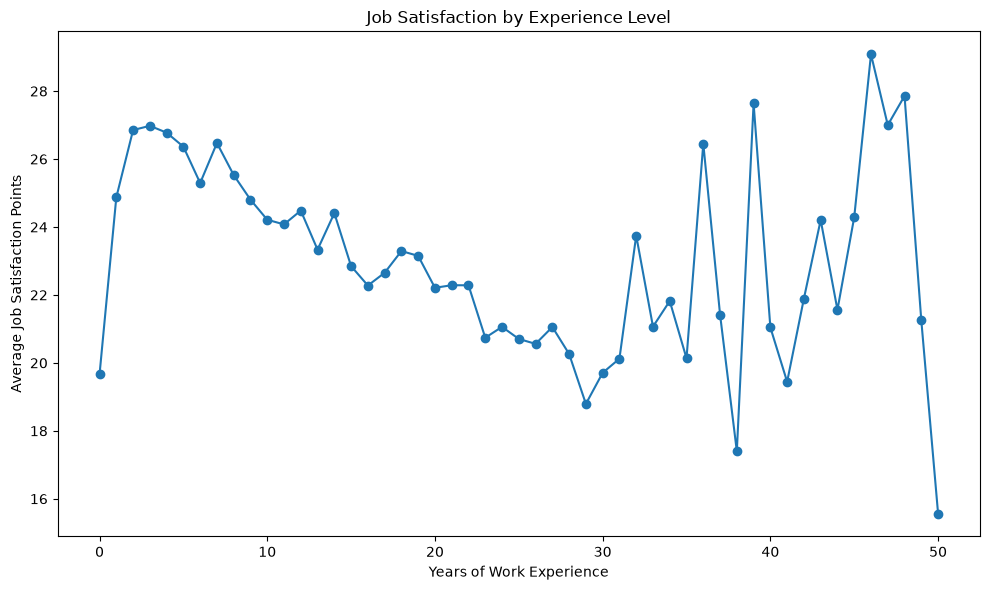

In [20]:
plot_df = df[["WorkExp", "JobSatPoints_6"]].copy()

plot_df["WorkExp"] = pd.to_numeric(plot_df["WorkExp"], errors="coerce")
plot_df["JobSatPoints_6"] = pd.to_numeric(
    plot_df["JobSatPoints_6"], errors="coerce"
)

plot_df = plot_df.dropna()

table = plot_df.groupby("WorkExp")["JobSatPoints_6"].mean().sort_index()

plt.figure(figsize=(10, 6))

plt.plot(table.index, table.values, marker="o")

plt.title("Job Satisfaction by Experience Level")
plt.xlabel("Years of Work Experience")
plt.ylabel("Average Job Satisfaction Points")

plt.tight_layout()
plt.show()

### Trends in Job Satisfaction and Compensation by Experience


##### 1.Line Chart of Median ConvertedCompYearly Over Experience Level

- This line chart will track how median compensation (`ConvertedCompYearly`) changes with increasing experience.

- Use a column such as `WorkExp` or another relevant experience-related column.


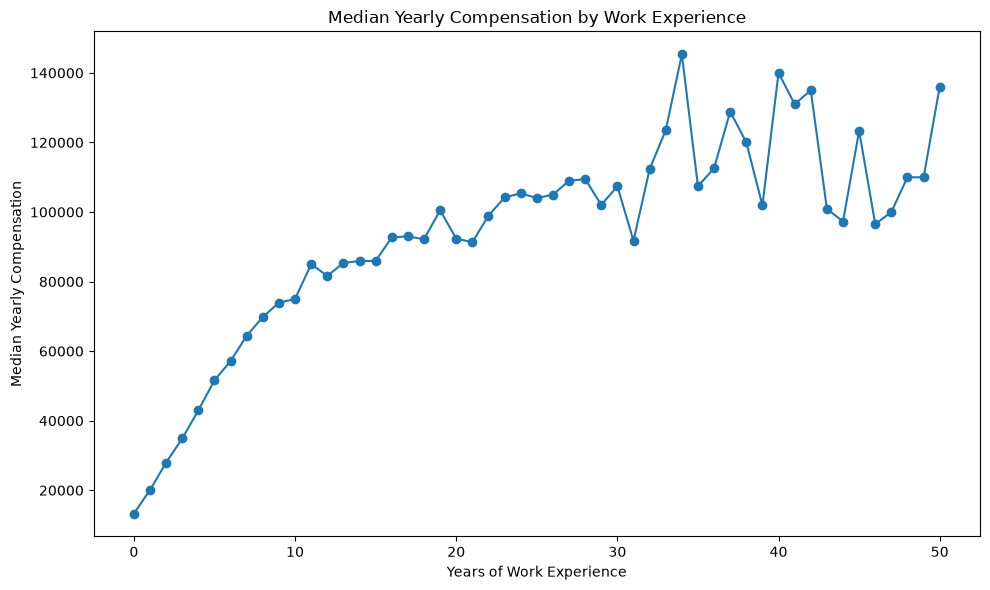

In [10]:
# Median compensation over experience level

plot_df = df[["WorkExp", "ConvertedCompYearly"]].copy()
plot_df["WorkExp"] = pd.to_numeric(plot_df["WorkExp"], errors="coerce")
plot_df["ConvertedCompYearly"] = pd.to_numeric(plot_df["ConvertedCompYearly"], errors="coerce")
plot_df = plot_df.dropna()

table = plot_df.groupby("WorkExp")["ConvertedCompYearly"].median().sort_index()

plt.figure(figsize=(10, 6))
plt.plot(table.index, table.values, marker="o")
plt.title("Median Yearly Compensation by Work Experience")
plt.xlabel("Years of Work Experience")
plt.ylabel("Median Yearly Compensation")
plt.tight_layout()
plt.show()

##### 2.Line Chart of Job Satisfaction (`JobSatPoints_6`) Across Experience Levels

- Create a line chart to explore trends in job satisfaction (`JobSatPoints_6`) based on experience level.

- This chart will provide insight into how satisfaction correlates with experience over time


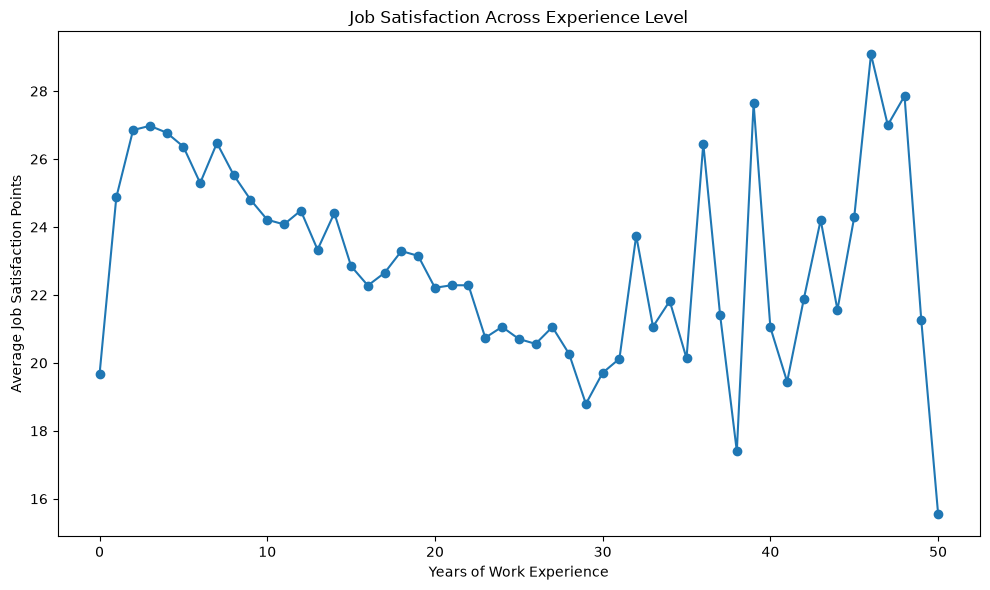

In [21]:
plot_df = df[["WorkExp", "JobSatPoints_6"]].copy()

plot_df["WorkExp"] = pd.to_numeric(plot_df["WorkExp"], errors="coerce")
plot_df["JobSatPoints_6"] = pd.to_numeric(
    plot_df["JobSatPoints_6"], errors="coerce"
)

plot_df = plot_df.dropna()

table = plot_df.groupby("WorkExp")["JobSatPoints_6"].mean().sort_index()

plt.figure(figsize=(10, 6))

plt.plot(table.index, table.values, marker="o")

plt.title("Job Satisfaction Across Experience Level")
plt.xlabel("Years of Work Experience")
plt.ylabel("Average Job Satisfaction Points")

plt.tight_layout()
plt.show()

### Summary


- Visualize the distribution of compensation across age groups to understand salary trends.

- Track changes in median compensation over various experience levels, identifying how earnings progress with experience.

- Examine trends in job satisfaction by experience, revealing how satisfaction varies throughout a developer's career.

These analyses allow for a deeper understanding of how factors like age and experience influence job satisfaction and compensation. By using line charts, you gained insights into continuous data patterns, which are invaluable for interpreting professional trends in the developer community.
